1. Imports & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Better display
pd.set_option('display.max_columns', None)

2. Load Data

In [3]:
orders = pd.read_csv('../data/raw/orders.csv', encoding='latin1')
order_details = pd.read_csv('../data/raw/order_details.csv', encoding='latin1')
pizzas = pd.read_csv('../data/raw/pizzas.csv', encoding='latin1')
pizza_types = pd.read_csv('../data/raw/pizza_types.csv', encoding='latin1')

3. Data Preprocessing

In [6]:
# Convert date & time correctly
orders['date'] = pd.to_datetime(orders['date'])  # auto-detect format
orders['time'] = pd.to_datetime(orders['time'], format='%H:%M:%S').dt.time

# Merge all tables
df = order_details.merge(pizzas, on='pizza_id')
df = df.merge(pizza_types, on='pizza_type_id')
df = df.merge(orders, on='order_id')

# Revenue column
df['revenue'] = df['quantity'] * df['price']

4. KPI ANALYSIS

Total Revenue

In [7]:
total_revenue = df['revenue'].sum()
print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 817860.05


Total Orders

In [8]:
total_orders = df['order_id'].nunique()
print("Total Orders:", total_orders)

Total Orders: 21350


Average Order Value

In [9]:
avg_order_value = total_revenue / total_orders
print("Average Order Value:", round(avg_order_value, 2))

Average Order Value: 38.31


5. SALES BY CATEGORY

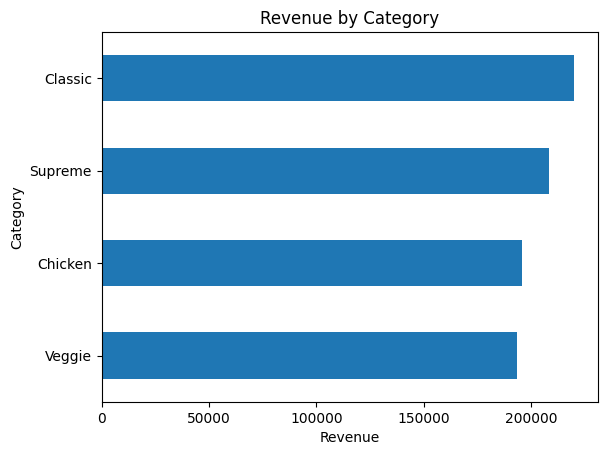

In [10]:
category_sales = df.groupby('category')['revenue'].sum().sort_values()

category_sales.plot(kind='barh')
plt.title("Revenue by Category")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

6. TOP & WORST PIZZAS

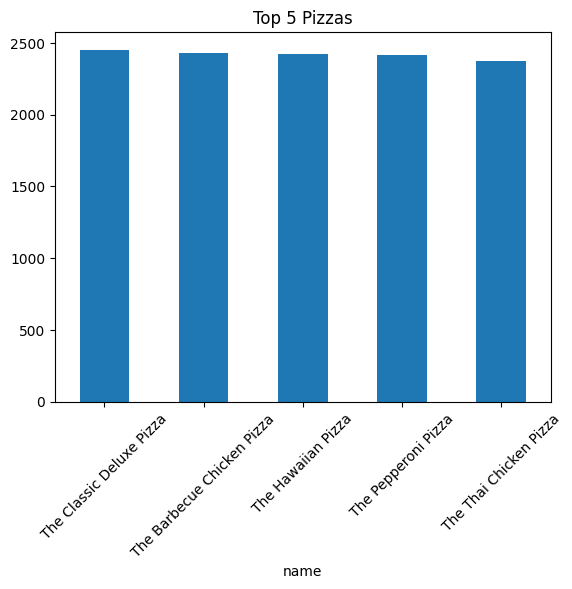

In [11]:
top_pizzas = df.groupby('name')['quantity'].sum().sort_values(ascending=False).head(5)

top_pizzas.plot(kind='bar')
plt.title("Top 5 Pizzas")
plt.xticks(rotation=45)
plt.show()

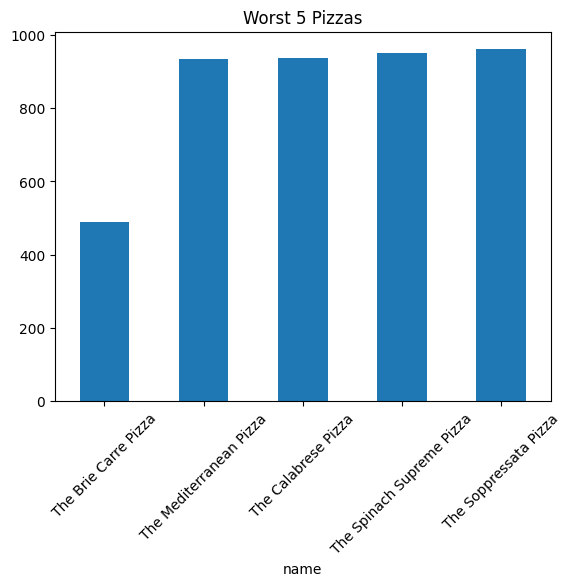

In [12]:
worst_pizzas = df.groupby('name')['quantity'].sum().sort_values().head(5)

worst_pizzas.plot(kind='bar')
plt.title("Worst 5 Pizzas")
plt.xticks(rotation=45)
plt.show()

7. TIME ANALYSIS

Extract Hour

In [13]:
orders['hour'] = pd.to_datetime(orders['time'], format='%H:%M:%S').dt.hour

Orders by Hour

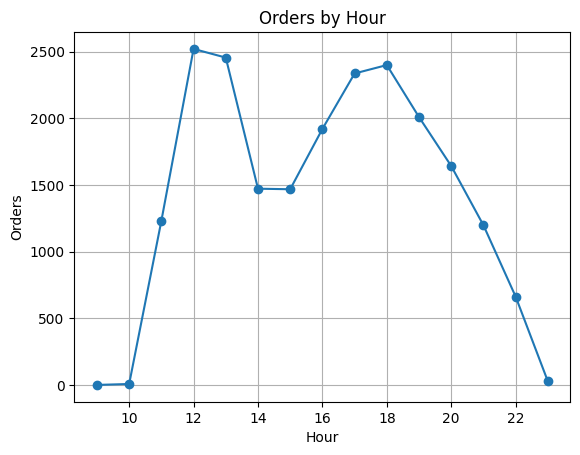

In [14]:
hourly_orders = orders.groupby('hour').size()

hourly_orders.plot(kind='line', marker='o')
plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Orders")
plt.grid()
plt.show()

Orders by Day

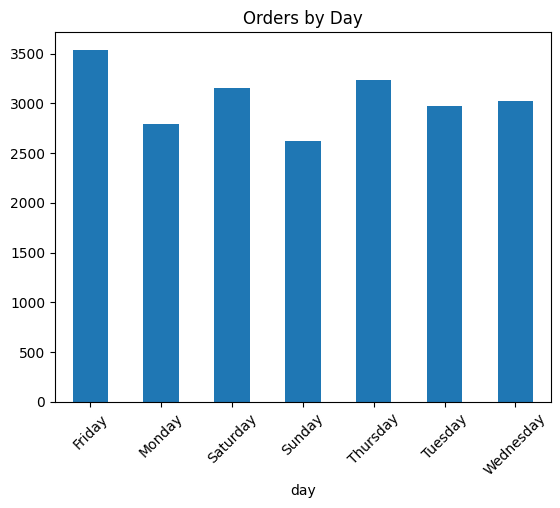

In [15]:
orders['day'] = orders['date'].dt.day_name()

daily_orders = orders.groupby('day').size()

daily_orders.plot(kind='bar')
plt.title("Orders by Day")
plt.xticks(rotation=45)
plt.show()

8. PIZZA SIZE ANALYSIS

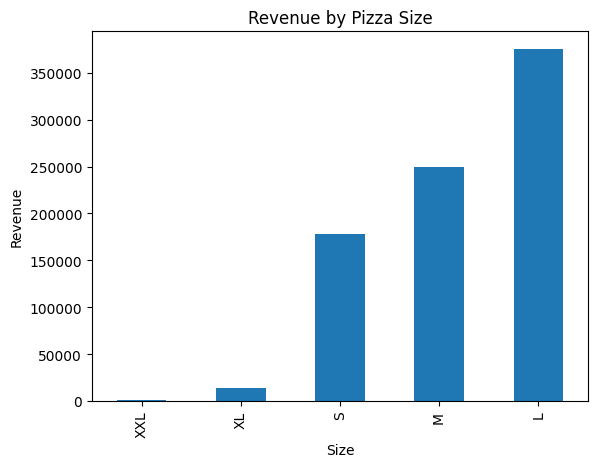

In [16]:
size_sales = df.groupby('size')['revenue'].sum().sort_values()

size_sales.plot(kind='bar')
plt.title("Revenue by Pizza Size")
plt.xlabel("Size")
plt.ylabel("Revenue")
plt.show()

9. REVENUE TREND

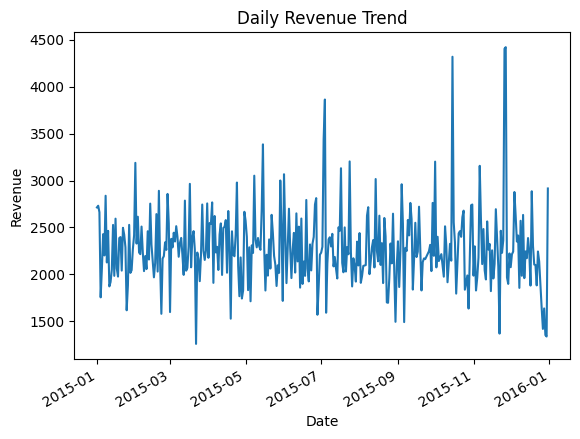

In [17]:
daily_revenue = df.groupby('date')['revenue'].sum()

daily_revenue.plot(kind='line')
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

10. CATEGORY CONTRIBUTION

In [18]:
category_percentage = (category_sales / total_revenue) * 100
print(category_percentage)

category
Veggie     23.682591
Chicken    23.955138
Supreme    25.456311
Classic    26.905960
Name: revenue, dtype: float64
